In [38]:
!pip install -U classiq
!pip install keyrings.alt

In [39]:
import keyring
from keyrings.alt.file import PlaintextKeyring
keyring.set_keyring(PlaintextKeyring())

In [40]:
import classiq
classiq.authenticate(overwrite=True)

/usr/local/lib/python3.12/dist-packages/classiq/_internals/authentication/token_manager.py:105: UserWarning: Overwriting an existing refresh token should only be done if it is compromised. Make sure this operation is necessary, and if not, remove the call to device registration.
  warnings.warn(


If a browser doesn't automatically open, please visit this URL from any trusted device to authenticate: https://auth.classiq.io/authorize?client_id=f6721qMOVoDAOVkzrv8YaWassRKSFX6Y&response_type=code&audience=https%3A%2F%2Fcadmium-be&redirect_uri=https%3A%2F%2Fauth.classiq.io%2Factivate%3Fuser_code%3DJKRP-SFJP&scope=offline_access
Your user code: JKRP-SFJP


In [41]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
from tabulate import tabulate

from classiq import *

In [87]:
# Inputs
n = 2  # dimension of vectors x(0) and b
t = 1
omega = 1
M = np.array([[0, 1], [-1*omega**2, 0]])
y0 = 1
vy0 = 2
x_0 = [y0, vy0]
b = [0, 0]

# Constants
k = 7
x_0_norm = np.linalg.norm(x_0)
b_norm = np.linalg.norm(b)
M_norm = np.linalg.norm(M)
# A = np.multiply(1/np.linalg.norm(M), M)
A = M

In [88]:
vs1 = []
c = 0


def VS1(t):
    global vs1
    global c
    c = 0
    c_m = np.zeros(k + 1)
    m_factorial = 1
    for i in range(k + 1):
        c_m[i] = (x_0_norm * (pow(t, i))) / m_factorial
        # c_m[i] = (x_0_norm * (pow(t * M_Norm, i))) / m_factorial
        c += c_m[i]
        m_factorial *= i + 1

    c = np.sqrt(c)

    if t == 0:
        vs1 = np.eye(k + 1, k + 1)
        return

    # Construct Unitary matrix with the first column as defined above in the markdown
    e = np.zeros(k + 1)
    e[0] = 1
    w = np.subtract([np.sqrt(c_m[i]) / c for i in range(k + 1)], e)
    vs1 = np.subtract(
        np.identity(k + 1), np.multiply(2 * (1 / np.inner(w, w)), np.outer(w, w))
    )

In [89]:
vs2 = []
d = 0


def VS2():
    global vs2
    global d
    d = 0
    d_m = np.zeros(k + 1)
    n_factorial = 1
    for i in range(1, k + 1):
        d_m[i - 1] = (b_norm * (pow(t * M_norm, i - 1))) / n_factorial
        d += d_m[i - 1]
        n_factorial *= i + 1
    d_m[k] = 0
    d = np.sqrt(d)

    if d == 0:
        vs2 = np.eye(k + 1, k + 1)
        return
    # Construct Unitary matrix with the first column as defined above in the markdown
    e = np.zeros(k + 1)
    e[0] = 1
    w = np.subtract([np.sqrt(d_m[i]) / d for i in range(k + 1)], e)
    vs2 = np.subtract(
        np.identity(k + 1), np.multiply(2 * (1 / np.inner(w, w)), np.outer(w, w))
    )

In [90]:
v = []
N = 0


def V():
    global v
    global N
    v = []
    N = np.sqrt(c * c + d * d)
    if N == 0:
        v = np.eye(2, 2)
    else:
        v.append([c / N, d / N])
        v.append([d / N, -c / N])
        v = np.array(v)

In [91]:
@qfunc
def encoding(x: QNum, ancilla: QNum, y: QBit, t: float):
    prob_x_0 = []
    for i in x_0:
        prob_x_0.append(i / x_0_norm)
    inplace_prepare_amplitudes(prob_x_0, 0.01, x)

    VS1(t)
    VS2()
    V()

    unitary(v, y)
    control(y == 0, lambda: unitary(vs1, ancilla), lambda: unitary(vs2, ancilla))

In [92]:
@qfunc
def evolution(x: QNum, ancilla: QNum):
    u_m = np.array([[1, 0], [0, 1]])

    for i in range(k + 1):
        U = u_m.copy()
        control(ancilla == i, lambda U=U: unitary(U, x))
        u_m = u_m @ A

In [93]:
@qfunc
def decoding(ancilla: QNum, y: QBit):
    ws1 = vs1.conj().T
    ws2 = vs2.conj().T
    w = v.conj().T
    control(y == 0, lambda: unitary(ws1, ancilla), lambda: unitary(ws2, ancilla))
    unitary(w, y)

In [94]:
T = int(np.log2(k + 1))  # no of ancilla qubits
dim = int(np.log2(n))  # no of work qubits


def create_main_for_t(t: float):
    @qfunc
    def main(x: Output[QNum[dim]], ancilla: Output[QNum[T]], y: Output[QBit]):
        allocate(x)
        allocate(ancilla)
        allocate(y)

        encoding(x, ancilla, y, t)
        evolution(x, ancilla)
        decoding(ancilla, y)

    return main

In [95]:
execution_preferences = ExecutionPreferences(
    num_shots=1,
    backend_preferences=ClassiqBackendPreferences(
        backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
    ),
)

In [96]:
omega = 1
y = []
y_dash = []
t_end = 10
t0 = np.pi / omega
dt = t0 / 30
quarter = t0 / 2
n_steps = int(quarter / dt)

for i in range(n_steps + 1):
    t = i * dt
    print(t)
    qmod = create_model(create_main_for_t(t))
    qmod = set_execution_preferences(qmod, execution_preferences)
    qprog = synthesize(qmod)
    job = execute(qprog)
    results = job.result_value()
    for j in results.parsed_state_vector:
        if int(j.bitstring[:-dim], 2) == 0:
            print(j.bitstring, " : ", np.linalg.norm(j.amplitude) * (N * N))
            if int(j.bitstring, 2) == 0:
                y.append(np.linalg.norm(j.amplitude) * (N * N))
            if int(j.bitstring, 2) == 1:
                y_dash.append(np.linalg.norm(j.amplitude) * (N * N))

def expand(t_end, t0, quarter, dt, y_base, ydash_base):
    y_full, ydash_full = [], []
    for i in range(int(t_end / dt) + 1):
        t = i * dt
        t_mod = t % t0
        q_idx = int(t_mod / quarter)
        if q_idx == 0:                        # Q1: direct
            idx = round(t_mod / dt)
            y_full.append(y_base[idx])
            ydash_full.append(ydash_base[idx])
        elif q_idx == 1:                      # Q2: swap only
            s = t_mod - 1 * quarter
            idx = round(s / dt)
            y_full.append(ydash_base[idx])
            ydash_full.append(y_base[idx])
    return y_full, ydash_full

y, y_dash = expand(t_end, t0, quarter, dt, y, y_dash)

0.0
00001  :  1.9999999999999878
00000  :  1.000000000000017
0.10471975511965977
00001  :  1.8845153274681856
00000  :  1.2035788219032257
0.20943951023931953
00001  :  1.7483835104684256
00000  :  1.3939709822732886
0.3141592653589793
00001  :  1.5930960335959596
00000  :  1.5690905025301924
0.41887902047863906
00000  :  1.7270187181488699
00001  :  1.420354226380142
0.5235987755982988
00000  :  1.8660252478386368
00001  :  1.232050536332084
0.6283185307179586
00000  :  1.9845868153319732
00001  :  1.0302475787421457
0.7330382858376183
00000  :  2.0814036475783007
00001  :  0.8171551013304419
0.8377580409572781
00000  :  2.155413173138526
00001  :  0.5951050018508567
0.9424777960769379
00000  :  2.2058007445763286
00001  :  0.36652453675294483
1.0471975511965976
00000  :  2.23200710864167
00001  :  0.13390785900140686
1.1519173063162573
00000  :  2.2337323480425173
00001  :  0.10021397684310218
1.2566370614359172
00000  :  2.21093601860033
00001  :  0.333304404180455
1.361356816555577

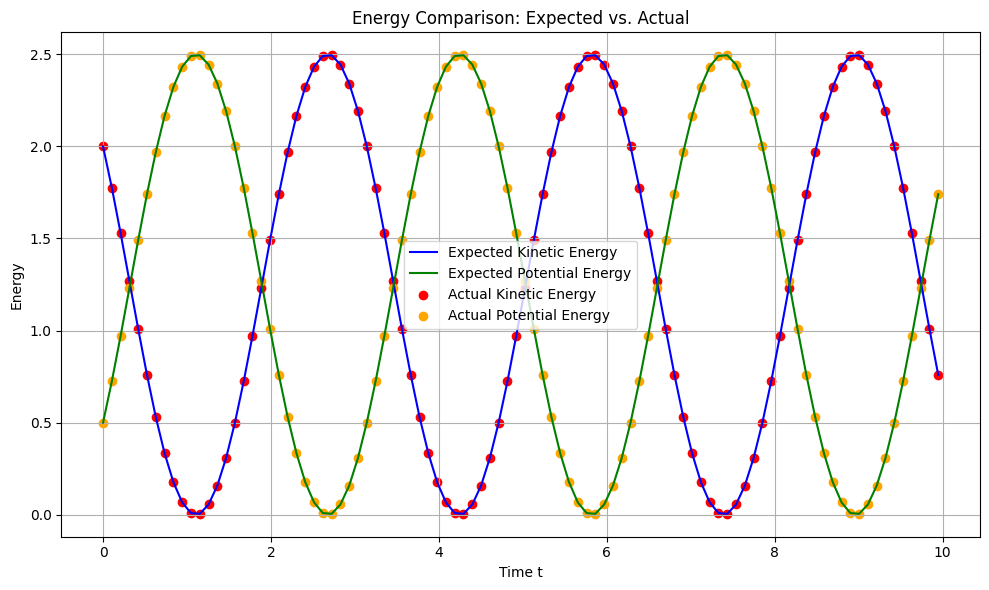

In [97]:
t_values = [i * dt for i in range(round(t_end / dt) + 1)]
def lookup(t, base):
    idx = round((t % t0) / dt)
    return base[idx]

y1      = [lookup(t, y)      for t in t_values]
y_dash1 = [lookup(t, y_dash) for t in t_values]

A0 = vy0/omega
B0 = y0

# Expected energies calculated from the formulas
y_values = [A0 * np.sin(t) + B0 * np.cos(t) for t in t_values]
ydash_values = [A0 * omega * np.cos(t) - B0 * omega * np.sin(t) for t in t_values]

kinetic_expected = [(ydash**2) / 2 for ydash in ydash_values]
potential_expected = [(omega**2) * (y**2) / 2 for y in y_values]


# Actual energies calculated from algorithm outputs:
kinetic_actual = [(ydash_val**2) / 2 for ydash_val in y_dash1]
potential_actual = [(omega**2) *(y_val**2) / 2 for y_val in y1]


plt.figure(figsize=(10, 6))


plt.plot(
    t_values,
    kinetic_expected,
    label="Expected Kinetic Energy",
    color="blue",
    linestyle="-",
)
plt.plot(
    t_values,
    potential_expected,
    label="Expected Potential Energy",
    color="green",
    linestyle="-",
)


plt.scatter(
    t_values, kinetic_actual, label="Actual Kinetic Energy", color="red", marker="o"
)
plt.scatter(
    t_values,
    potential_actual,
    label="Actual Potential Energy",
    color="orange",
    marker="o",
)


plt.xlabel("Time t")
plt.ylabel("Energy")
plt.title("Energy Comparison: Expected vs. Actual")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [98]:
results = [
    [
        i * dt,
        kinetic_expected[i],
        kinetic_actual[i],
        potential_expected[i],
        potential_actual[i],
    ]
    for i in range(round(t_end / dt) + 1)
]
table = tabulate(
    results,
    headers=[
        "t",
        "Kinetic expected",
        "Kinetic actual",
        "Potential expected",
        "Potential actual)",
    ],
    numalign="center",
    tablefmt="github",
)
print(table)

error_bound_potential = [
    100 * np.abs(a - e) / a for a, e in zip(potential_expected, potential_actual)
    if a > 1e-6
]
error_bound_kinetic = [
    100 * np.abs(a - e) / a for a, e in zip(kinetic_expected, kinetic_actual)
    if a > 1e-6
]

print("\n\nkinetic accuracy (Mean): ", 100 - np.mean(error_bound_kinetic), "%")
print("potential accuracy (Mean): ", 100 - np.mean(error_bound_potential), "%")

|    t     |  Kinetic expected  |  Kinetic actual  |  Potential expected  |  Potential actual)  |
|----------|--------------------|------------------|----------------------|---------------------|
|    0     |         2          |        2         |         0.5          |         0.5         |
| 0.10472  |       1.7757       |      1.7757      |       0.724301       |      0.724301       |
| 0.20944  |      1.52842       |     1.52842      |       0.971578       |      0.971578       |
| 0.314159 |      1.26898       |     1.26898      |       1.23102        |       1.23102       |
| 0.418879 |       1.0087       |      1.0087      |        1.4913        |       1.4913        |
| 0.523599 |      0.758975      |     0.758974     |       1.74103        |       1.74103       |
| 0.628319 |      0.530706      |     0.530705     |       1.96929        |       1.96929       |
| 0.733038 |      0.333874      |     0.333871     |       2.16613        |       2.16612       |
| 0.837758 |      0.